# Import et export de la clé d'API dans une variable d'environnement

In [1]:
import os
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
#don't forget pip install -U langchain-ollama
from langchain_ollama import ChatOllama
from datetime import datetime
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage
from langchain_core.messages.base import BaseMessage

# Création du state

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]
    next_node: str 


graph_builder = StateGraph(State)

In [3]:
LLM_MODEL = "llama3.2:3b"
#LLM_MODEL_NAME = "llama3"
#OLLAMA_API_URL = "http://localhost:11434/api/chat"

llm = ChatOllama(model = LLM_MODEL, temperature=0.7)


In [4]:
#test
result = llm.invoke([HumanMessage(content="Est-ce qu'il fait beau aujourd'hui ?")])
print(result)
              


content="Je suis désolé, mais je ne peux pas savoir si il fait beau ou pluvieux dans votre endroit. Cependant, je peux vous suggérer quelques façons de trouver cette information :\n\n1. **Vérifiez la météo en ligne** : Vous pouvez consulter des sites web de météo tels que Météo France, AccuWeather ou le service météo du gouvernement local pour obtenir les prévisions météorologiques actuelles.\n2. **Demandez à quelqu'un qui connaît votre région** : Si vous êtes en contact avec quelqu'un qui vit dans votre région, vous pouvez lui poser la question et demander si il fait beau aujourd'hui.\n3. **Vérifiez les réseaux sociaux** : Les réseaux sociaux comme Twitter ou Facebook peuvent être une bonne source d'information sur le temps actuel.\n\nJ'espère que ces suggestions vous aideront à trouver les informations que vous cherchez !" additional_kwargs={} response_metadata={'model': 'llama3.2:3b', 'created_at': '2025-07-18T09:23:21.205811407Z', 'done': True, 'done_reason': 'stop', 'total_duratio

# Création des tools du router

In [5]:
selector_llm = ChatOllama(model = LLM_MODEL, temperature=0)

In [6]:
def get_date(state:State):
    """Donne la date actuelle."""
    from datetime import datetime
    current_date = f"date: {datetime.now().strftime("%Y-%m-%d")}"

    return {
        "messages": state["messages"] + [
            SystemMessage(content=current_date)
        ],
        "next_node": "chatbot",
    }

def get_time(state:State):
    """Donne l'heure actuelle."""
    from datetime import datetime
    current_date = f"heure: {datetime.now().strftime("%H:%M:%S")}"

    return {
        "messages": state["messages"] + [
            SystemMessage(content=current_date)
        ],
        "next_node": "chatbot",
    }

In [7]:
def chatbot(state: State):

    prompt = """Vous êtes un assistant intelligent qui répond à des questions de l'utilisateur.
        Vous pouvez utiliser la date et l'heure du jour si l'information se trouve dans l'historique des messages pour répondre : 
        """
    
    messagelist : list[BaseMessage] = state["messages"]
    for message in messagelist :
        prompt = prompt + str(message.name) + ":" + str(message.content) + "\n"

    prompt = prompt + "Répondez simplement, par une réponse courte si possible"
        
    llm_invokation : BaseMessage = llm.invoke(prompt)

    output_messages = state["messages"] + [llm_invokation]
    return {
        "messages": output_messages,
        "next_node": "chatbot"
    }


In [8]:
tools = [
    get_date,
    get_time
]

In [9]:
def select_tool(state: State):
    """Choisit l'outil à appeler et mémorise le choix."""
    resp = selector_llm.invoke(f"""
        Vous êtes **ToolSelector**, un agent interne dont la seule tâche est de décider quel outil l'agent externe doit appeler ensuite.
        Vous ne répondez JAMAIS directement à l'utilisateur final.

        Description des outils :
        {', '.join(f"{tool.__name__} : {tool.__doc__}" for tool in tools)}

        Vous pouvez utiliser les messages suivants pour décider quel outil appeler ensuite :
        [{state["messages"]}]

        N'oubliez pas que votre réponse doit être l'une des suivantes : {', '.join(tool.__name__ for tool in tools)} ou "chatbot". La réponse doit être un mot simple.
        Exemple 1 : chatbot
        Exemple 2 : get_date
        Exemple 3 : get_time

                           """)
    
    choice = "chatbot"
    for tool in tools :
        if tool.__name__ in resp.content :
            choice = tool.__name__
            break

    print("next node:",choice)
    return {
        "messages": state["messages"],
        "next_node": choice,
    }

# Création des noeuds et des arrêtes

In [10]:
graph_builder.add_node("selector", select_tool)
graph_builder.add_node("chatbot", chatbot)

for node_fn in tools:
    graph_builder.add_node(node_fn.__name__, node_fn)

graph_builder.add_edge(START, "selector")

selections_possibles = {node_fn.__name__:node_fn.__name__ for node_fn in tools}
selections_possibles["chatbot"] = "chatbot"

graph_builder.add_conditional_edges(
    "selector",
    lambda state: state["next_node"],
    selections_possibles,
)
# Après chaque tool, on repasse par chatbot 
for tool in (tool.__name__ for tool in tools):
    graph_builder.add_edge(tool, "chatbot")

graph_builder.add_edge("chatbot", END)

In [11]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph = graph_builder.compile(interrupt_before=["get_date", "get_time"], checkpointer=memory)

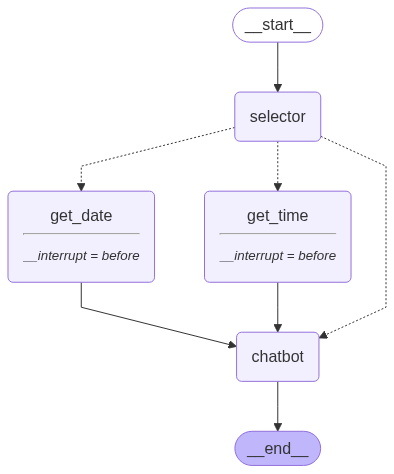

In [ ]:
from IPython.display import Image, display

try:
    png_data = graph.get_graph().draw_mermaid_png()
    with open("test-agent_ollama_interaction.png", "wb") as f:
        f.write(png_data)

    display(Image(png_data))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [13]:
import langgraph_sdk

from typing import Any
def print_event(event: dict[str|Any]|Any) :
    # state = event['state']
    event_name = next(iter(event.keys()))
    messages = event[event_name]
    last_message = messages[-1]
    last_message_name = type(last_message).__name__
    last_message_content = last_message.content
    print(f"{event_name} : {last_message_name} : {last_message_content}")
    # print(f"Node: {event['metadata'].get('langgraph_node','')}. Type: {event['event']}. Name: {event['name']}")

def stream_graph_updates(user_input: str, thread_id:int):
 
    # config = {"configurable": {"thread_id": "666"}}
    thread = {"configurable": {"thread_id": str(thread_id)}}
    initial_state = State( messages=[HumanMessage(content=user_input)])

    state = graph.get_state(thread)
    print (f"DEBUT, next = {state.next}")

    while True :
        for event in graph.stream(initial_state, thread, stream_mode="values"):
            # for m in event["messages"] :
            #     m.pretty_print()
            print_event(event)

        state = graph.get_state(thread)
        # print (state)
        if (state.next) :  
            print(f"  INTERUPTION, next = {state.next}\n")
            initial_state = None
        else :
            print ("FIN\n")
            break


stream_graph_updates("Quel jour sommes nous ?", 1)
stream_graph_updates("quelle heure est-il?", 2)
# print()
# stream_graph_updates("donne moi le jour et l'heure actuelle")

DEBUT, next = ()
messages : HumanMessage : Quel jour sommes nous ?
next node: get_date
messages : HumanMessage : Quel jour sommes nous ?
  INTERUPTION, next = ('get_date',)

messages : HumanMessage : Quel jour sommes nous ?
messages : SystemMessage : date: 2025-07-18
messages : AIMessage : Nous sommes le jeudi 18 juillet 2024.
FIN

DEBUT, next = ()
messages : HumanMessage : quelle heure est-il?
next node: get_time
messages : HumanMessage : quelle heure est-il?
  INTERUPTION, next = ('get_time',)

messages : HumanMessage : quelle heure est-il?
messages : SystemMessage : heure: 11:23:25
messages : AIMessage : C'est 12h00.
FIN

